<figure>
  <IMG src="figures/logo-esi-sba.png" WIDTH=300 height="100" ALIGN="right">
</figure>

# Practical Trainining Series on Software Engineering For Data Science  
*By Dr. Belkacem KHALDI (b.khaldi@esi-sba.dz)*

# Notebook 5: Data Processing & Cleaning for Data Science: Data Ingestion and Wrangling with Pandas

The purpose of this [Jupyter Notebook] is to getting you introduced to the Data Processing & Cleaning for Data
Science: Data Ingestion and Wrangling with Pandas. It provides a set of practical Training challenges that allow grasping the different concepts presented in the lecture 5.

## Challenge 1
1. Connect to the `chinook.db` sqlite3 database available in the folder data.
2. Find the genre names with the longest average song length.

`Hint:`
join the tables with the genre name and song length and use the SQLite aggregate
function for the average along with a GROUP BY clause.


In [47]:
#Your Solution here

#challenge 1: 1. database connection

import sqlite3
import pandas as pd

conn = sqlite3.connect('data/chinook.db')
cursor = conn.cursor()

In [48]:
#challenge 1: 2. the genre names with the longest average song length

query = """
SELECT 
    g.Name AS GenreName,
    AVG(t.Milliseconds) AS AvgSongLength
FROM tracks t
JOIN genres g ON t.GenreId = g.GenreId
GROUP BY g.Name
ORDER BY AvgSongLength DESC;
"""


df = pd.read_sql_query(query, conn)
df.head()

# Get the top genre(s)
df['AvgSongLength'] = df['AvgSongLength'].astype(int)
longest_avg = df[df['AvgSongLength'] == df['AvgSongLength'].max()]
print(longest_avg)


          GenreName  AvgSongLength
0  Sci Fi & Fantasy        2911783


## Challenge 2: Ingesting, Wrangling and Analyzing  iTune data

You've started a new data science position at the iTune department at Apple Company. 
The department wants to build, test, and evaluate new machine learning recommendation song models using a different source of data: in Excel file, in a csv file, and in the chinook.db SQLite database. They want you proceed with the data ingsestion and data wrangling procedures to provide a clean dataset to be used later for their machine learning based recommendation songs models.  

1. They particlarly asked you to load, clean, and analyze, and then deliver your results to the executive team and president.
You should deliver a small summary of your EDA work from pandas and save your cleaned and prepared data as a new Excel file. The data files are `chinook_data.xlsx`, `chinook_data.csv`, and `chinook.db` on the data folder existed within this notebook.

`Hint:`
1. Follow the procedures in Lecture 5 - Slides: 13-17 - For data ingestion (Data loading from different sources).

2. Follow and test the procedures in Lecture 5 - Slides:18-22 - For Basic Exploratory Data Analysis (EDA).

3. Follow and test the procedures in Lecture 5 - Slides:23-27 - For Basic Data Cleaning Operations.

4. To save your cleaned dataset in an excel file use the pandas built-in method: `pandas.DataFrame.to_excel`.


In [49]:
#imports

import pandas as pd
import sqlite3
import numpy as np
import matplotlib.pyplot as plt

In [50]:
# data ingestion

csv_df = pd.read_csv('data/chinook_data.csv', sep=',', decimal='.')
excel_df = pd.read_excel('data/chinook_data.xlsx')
conn = sqlite3.connect('data/chinook.db')

query = """
SELECT 
    t.Name as Track,
    t.Composer,
    t.Milliseconds, 
    t.Bytes,
    t.UnitPrice,
    g.Name as Genre,
    a.Title as Album,
    r.Name as Artist
FROM tracks t
JOIN genres g ON t.GenreId = g.GenreId
JOIN albums a ON t.AlbumId = a.AlbumId
JOIN artists r ON a.ArtistId = r.ArtistId
"""

sql_df = pd.read_sql_query(query, conn)
conn.close()

print("Data loaded successfully!")
print(f"CSV records: {len(csv_df)}")
print(f"Excel records: {len(excel_df)}")
print(f"SQL records: {len(sql_df)}")

Data loaded successfully!
CSV records: 303
Excel records: 215
SQL records: 3503


In [51]:
# combining data into one frame

itunes_df = pd.concat([csv_df, excel_df, sql_df], ignore_index=True)
print(f"Combined dataset: {len(itunes_df)} records")

Combined dataset: 4021 records


In [52]:
# data examination EDA

print("First 5 rows:")
print(itunes_df.head())

print("\nLast 5 rows:")
print(itunes_df.tail())

print(f"\nData shape: {itunes_df.shape}")

print("\nData info:")
print(itunes_df.info())

print("\nMissing values:")
print(itunes_df.isna().sum())

First 5 rows:
                                    Track                           Composer  \
0  All the Best Cowboys Have Daddy Issues                                NaN   
1                               Beira Mar                       Gilberto Gil   
2                                  Brasil  Milton Nascimento, Fernando Brant   
3                            Ben Franklin                                NaN   
4            O Último Romântico (Ao Vivo)                                NaN   

   Milliseconds      Bytes  UnitPrice     Genre  \
0       2555492  211743651       1.99  TV Shows   
1        295444    9597994       0.99     Latin   
2        155428    5252560       0.99     Latin   
3       1271938  264168080       1.99    Comedy   
4        231993    7692697       0.99     Latin   

                                             Album             Artist  
0                                   Lost, Season 1               Lost  
1                                        Unplugged    

In [53]:
# statistical anlysis EDA

print("Statistical summary:")
print(itunes_df.describe())

print("Statistical summary for numeric columns:")
numeric_df = itunes_df.select_dtypes(include=[np.number])
print(numeric_df.describe())
if not numeric_df.empty:
    print("\nCorrelation matrix:")
    print(numeric_df.corr())
else:
    print("\nNo numeric columns for correlation matrix")

# Value counts for categorical data
print("\nGenre distribution:")
print(itunes_df['Genre'].value_counts())

print("\nArtist distribution (top 10):")
print(itunes_df['Artist'].value_counts().head(10))

Statistical summary:
       Milliseconds         Bytes    UnitPrice
count  4.021000e+03  4.021000e+03  4021.000000
mean   3.927276e+05  3.311048e+07     1.050184
std    5.337745e+05  1.042268e+08     0.237857
min    1.071000e+03  3.874700e+04     0.990000
25%    2.069680e+05  6.372433e+06     0.990000
50%    2.554770e+05  8.102839e+06     0.990000
75%    3.217240e+05  1.025143e+07     0.990000
max    5.286953e+06  1.059546e+09     1.990000
Statistical summary for numeric columns:
       Milliseconds         Bytes    UnitPrice
count  4.021000e+03  4.021000e+03  4021.000000
mean   3.927276e+05  3.311048e+07     1.050184
std    5.337745e+05  1.042268e+08     0.237857
min    1.071000e+03  3.874700e+04     0.990000
25%    2.069680e+05  6.372433e+06     0.990000
50%    2.554770e+05  8.102839e+06     0.990000
75%    3.217240e+05  1.025143e+07     0.990000
max    5.286953e+06  1.059546e+09     1.990000

Correlation matrix:
              Milliseconds     Bytes  UnitPrice
Milliseconds      1.000

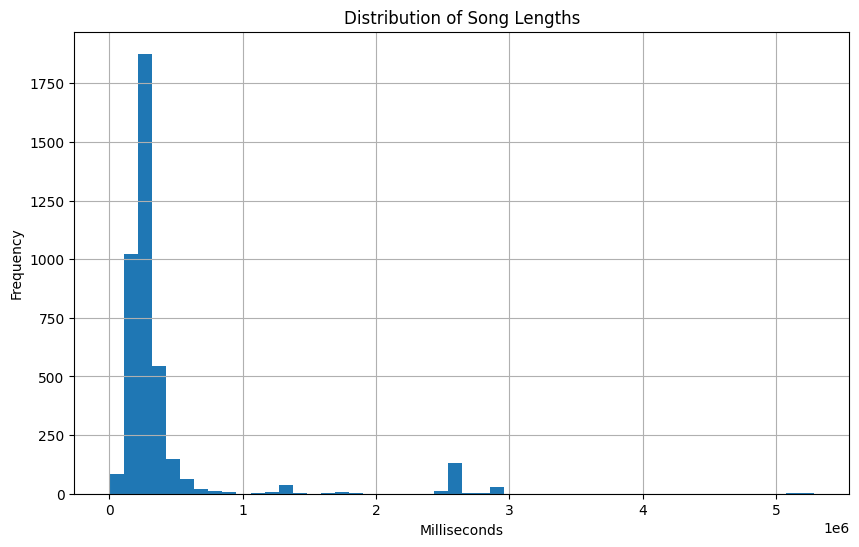

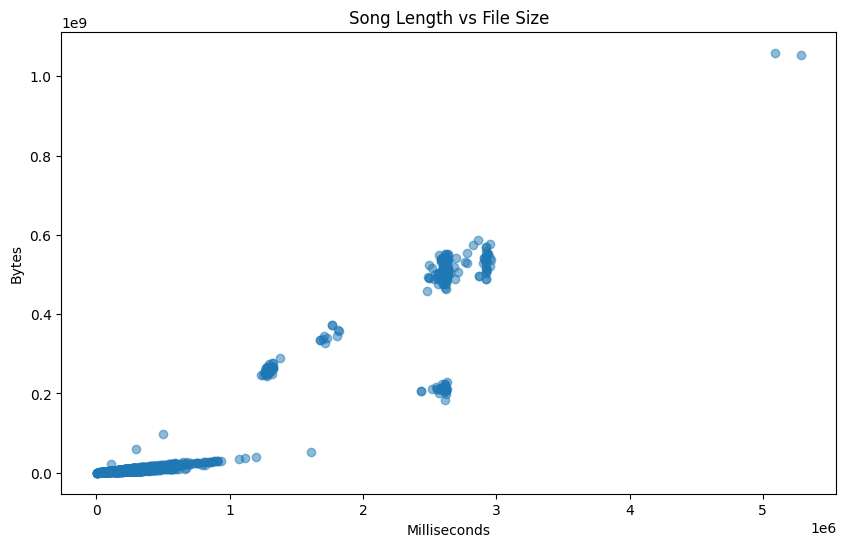

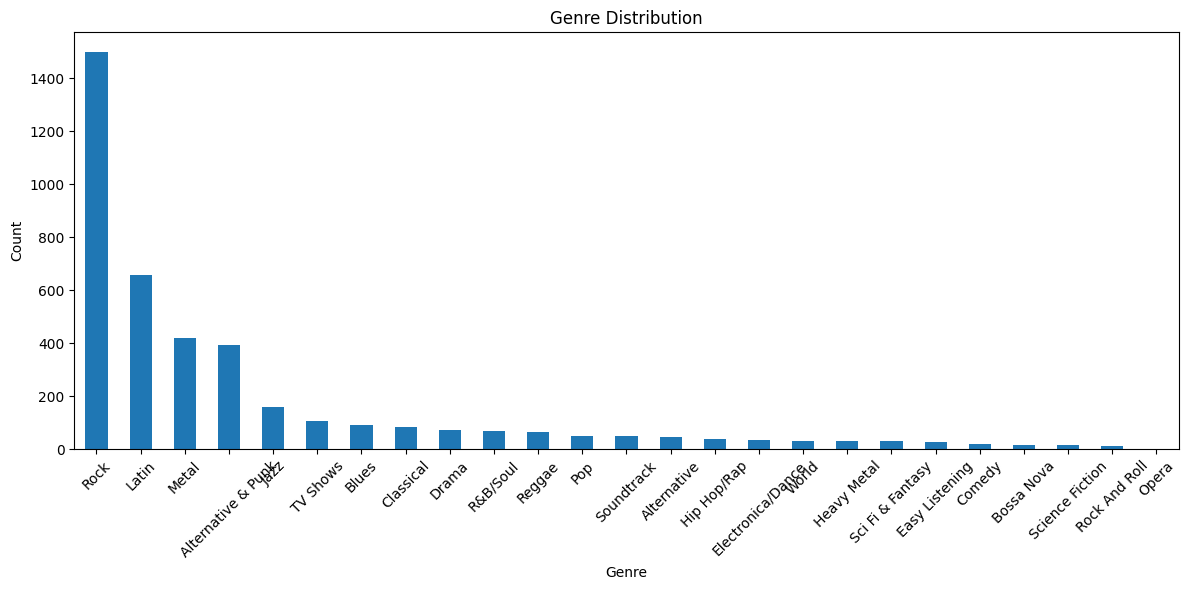

In [54]:
# data visualization EDA

# Histogram of song lengths
plt.figure(figsize=(10, 6))
itunes_df['Milliseconds'].hist(bins=50)
plt.title('Distribution of Song Lengths')
plt.xlabel('Milliseconds')
plt.ylabel('Frequency')
plt.show()

# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(itunes_df['Milliseconds'], itunes_df['Bytes'], alpha=0.5)
plt.title('Song Length vs File Size')
plt.xlabel('Milliseconds')
plt.ylabel('Bytes')
plt.show()

# Bar plot of genres
plt.figure(figsize=(12, 6))
itunes_df['Genre'].value_counts().plot(kind='bar')
plt.title('Genre Distribution')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [55]:
# data cleaning

non_music_genres = ['TV Shows', 'Drama', 'Comedy', 'Sci Fi & Fantasy', 'Science Fiction']
itunes_clean = itunes_df[~itunes_df['Genre'].isin(non_music_genres)]
print(f"After removing non-music genres: {len(itunes_clean)} records")

After removing non-music genres: 3779 records


In [56]:
# handling missing values

# fill missing composers with 'Unknown'
itunes_clean['Composer'] = itunes_clean['Composer'].fillna('Unknown')

# fill missing numeric values with median
numeric_columns = ['Milliseconds', 'Bytes', 'UnitPrice']
for col in numeric_columns:
    if col in itunes_clean.columns:
        itunes_clean[col] = itunes_clean[col].fillna(itunes_clean[col].median())

print("Missing values after cleaning:")
print(itunes_clean.isna().sum())

Missing values after cleaning:
Track           0
Composer        0
Milliseconds    0
Bytes           0
UnitPrice       0
Genre           0
Album           0
Artist          0
dtype: int64


C:\Users\dell\AppData\Local\Temp\ipykernel_29324\3462899198.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  itunes_clean['Composer'] = itunes_clean['Composer'].fillna('Unknown')
C:\Users\dell\AppData\Local\Temp\ipykernel_29324\3462899198.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  itunes_clean[col] = itunes_clean[col].fillna(itunes_clean[col].median())
C:\Users\dell\AppData\Local\Temp\ipykernel_29324\3462899198.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice fro

In [57]:
# removing outliers

def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Remove outliers from numeric columns
for col in ['Milliseconds', 'Bytes']:
    if col in itunes_clean.columns:
        initial_count = len(itunes_clean)
        itunes_clean = remove_outliers(itunes_clean, col)
        removed = initial_count - len(itunes_clean)
        print(f"Removed {removed} outliers from {col}")

print(f"Final record count: {len(itunes_clean)}")

Removed 226 outliers from Milliseconds
Removed 47 outliers from Bytes
Final record count: 3506


In [58]:
# duplicates 

initial_duplicates = itunes_clean.duplicated().sum()
itunes_clean = itunes_clean.drop_duplicates()
print(f"Removed {initial_duplicates} duplicate rows")

# Ensure correct data types
itunes_clean['Milliseconds'] = itunes_clean['Milliseconds'].astype('int64')
itunes_clean['Bytes'] = itunes_clean['Bytes'].astype('int64')

print("\nFinal data types:")
print(itunes_clean.dtypes)

Removed 451 duplicate rows

Final data types:
Track            object
Composer         object
Milliseconds      int64
Bytes             int64
UnitPrice       float64
Genre            object
Album            object
Artist           object
dtype: object


In [59]:
# standardization 

itunes_clean['Genre'] = itunes_clean['Genre'].str.title()
itunes_clean['Artist'] = itunes_clean['Artist'].str.title()

# Add new columns (data transformations)
itunes_clean['Minutes'] = itunes_clean['Milliseconds'] / 60000
itunes_clean['Minutes'] = itunes_clean['Minutes'].round(2)

print("Data standardization completed!")

Data standardization completed!


In [60]:
# saving data

itunes_clean.to_excel('cleaned_itunes_data.xlsx', index=False)
print("Cleaned data saved to 'cleaned_itunes_data.xlsx'")

Cleaned data saved to 'cleaned_itunes_data.xlsx'


## Challenge 3: Ingesting, Wrangling and Analyzing Bitcoin price data


You have just joined a financial company as a new data scientist. The company is  interested in the Bitcon market and you are working with a team that aims to ingest data and then clean, and analyse the final dataset to be used later to build and evaluate machine learning models for Bitcon Price forecasting.

The company is working with two datasets coming from two different sources and is only interested in the `BTCUSD` currency: 
1. One dataset is json file locally existed in the data folder: `bitcoin_price.json`. This file contains data up to `2020-11-27`
2. The other uses a real time data flow that comes from yahoo finance api service. The company wants to collect real time data beginning from `2020-11-28` to `2022-10-31`.

You are asked to do the required checklist procedures and operations to load, clean, and analyse, and then deliver your results to the executive team with providing a short summaray of your prelimanary EDA work from pandas and save the cleaner dataset as a new csv file. 
Note that the 

`Hint:`

1. To load a json file into a dataframe use the snipet code below:

```python
import json

with open('<path_to_your_json_file>') as f:
    data = json.load(f)

btc_df_jsn=pd.DataFrame.from_dict(data)
```

This code uses the `json` built-in python module to open a json file and load it in an object data. Then we use the `from_dict()` pandas method to transform the json data into a DataFrame.

2. To get real time data flow from the yahoo finance api sevice we will use the `yfinance` module. 
    * So, first install the module in your environment using  `conda install yfinance`.
    * Then use the code below to get real data. Test with the periode from `2020-01-01` to `2024-10-31`.

```python
import yfinance as yf

btc_yf_df = yf.download('BTC-USD', # The currency we are intersted in
                   start='<start_date>', # The starting date
                   end='<end_date>', # The starting date
                   interval='1d' # The frequency of collecting the data. here 1 day
                  )
```

3. Get a look of the two DataFrames and see what are the common columns and what differ one to another.
    * You will notice that the  json DataFrame is indexed numericaly wherease the yahoo DataFrame is indexed by Date. So, you have to uniform the index for both DataFrames. In this case we will change the json DataFrame  index by Date.
        1. To do that, first rename the column `time` to `Date` by using the built-in pandas method: `rename()` as follows:
        
        ```python
        rename(columns ={'<old_col_name>':'<new_col_name>'}, inplace = True)
         ```
         
        2. What is the datatype of the new Date column in the json DataFrame?
            * You will notice that it is a `datetime64[ns]` datatype, which means the number of seconds since 1-1-1970. To make it date fomat like the yahoo DataFrame, convert the column to a pandas datetime datatype by using the following code: 
         
          ```python
              btc_df['<column_name>'] = pd.to_datetime(btc_df['<column_name>'], unit='ms')
          ```
         
        3. To change the index of your dataframe use the `set_index` built-in pandas function:
        ```python
              set_index('<column_name>', inplace=True)
        ```
            * The remaining common columns labels in both DataFrames are not uniformed. The json DataFrame uses lowercase strings,  while the yahoo DataFrame uses a first letter world uppercase string.
                  1. Change the column labels of the yahoo DataFrame to lowercase strings. Adjust the following code accordingly:
             ```python
                data_frame.columns= data_frame.columns.str.lower()
             ```
             
4. Concatenate the two dataframe into one dataset.
5. Do The basic EDA cheklist procedures on the resulting dataset:
   * Do few time series plots: 
       * open, close, high, low, volume with regards to Date
   * Print the correlation matrix.
6. Do the General Data Cleaning Checklist operations to see if ther is still cleaning operations to accomplish.
    * Most particularly, you will notice a NaN values in both `adj close` and `symbole` columns. What is your suggestion to deal with this missing values given that the company is not interest at all on the `adj close` data. 	
7. Save your cleaner dataframe into a csv file.
    * Use the `pandas.DataFrame.to_csv` method.
             

In [61]:
#1 load the jason file
import pandas as pd
import json
import matplotlib.pyplot as plt
import yfinance as yf

btc_yf_df = yf.download('BTC-USD',
                        start='2020-01-01',
                        end='2022-10-31',
                        interval='1d')

with open("data\\bitcoin_price.json") as f:
    data = json.load(f)

btc_df_jsn=pd.DataFrame.from_dict(data)

print(btc_yf_df.head())
print(btc_df_jsn.head())
print(" the index " , btc_df_jsn.index) 

#  will see that the index is by default (from 0 to number of samples )
# integrating data from Yahoo Finance API and local JSON file with different structures

C:\Users\dell\AppData\Local\Temp\ipykernel_29324\1070206463.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc_yf_df = yf.download('BTC-USD',
[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open       Volume
Ticker          BTC-USD      BTC-USD      BTC-USD      BTC-USD      BTC-USD
Date                                                                       
2020-01-01  7200.174316  7254.330566  7174.944336  7194.892090  18565664997
2020-01-02  6985.470215  7212.155273  6935.270020  7202.551270  20802083465
2020-01-03  7344.884277  7413.715332  6914.996094  6984.428711  28111481032
2020-01-04  7410.656738  7427.385742  7309.514160  7345.375488  18444271275
2020-01-05  7411.317383  7544.497070  7400.535645  7410.451660  19725074095
   symbol           time        open       close       high        low  \
0  btcusd  1364688000000   92.500000   93.033000   93.74999   91.00000   
1  btcusd  1364774400000   93.250000  103.999000  105.90000   92.49999   
2  btcusd  1364860800000  104.000000  118.229354  118.38670   99.00000   
3  btcusd  1364947200000  117.958261  134.700000  146.88000  101.51088   
4  btcusd  13650336000

In [62]:
#2. get real data from yahoo faniance api service 

btc_df_jsn.rename(columns={'time': 'Date'}, inplace=True) # rename the time  by date 
btc_df_jsn['Date'] = pd.to_datetime(btc_df_jsn['Date'], unit='ms') # trnasforming the time here to date 

# index by date (we are indexing here by the date )
print(btc_df_jsn.head())
btc_df_jsn.set_index('Date', inplace=True)
print(" the index " , btc_df_jsn.index)

# JSON data used millisecond timestamps requiring conversion to match Yahoo Finance datetime format

   symbol       Date        open       close       high        low  \
0  btcusd 2013-03-31   92.500000   93.033000   93.74999   91.00000   
1  btcusd 2013-04-01   93.250000  103.999000  105.90000   92.49999   
2  btcusd 2013-04-02  104.000000  118.229354  118.38670   99.00000   
3  btcusd 2013-04-03  117.958261  134.700000  146.88000  101.51088   
4  btcusd 2013-04-04  134.716560  132.899000  143.00000  119.00000   

         volume  
0   3083.079791  
1   5224.401313  
2   8376.527478  
3  12996.245072  
4   6981.668305  
 the index  DatetimeIndex(['2013-03-31', '2013-04-01', '2013-04-02', '2013-04-03',
               '2013-04-04', '2013-04-05', '2013-04-06', '2013-04-07',
               '2013-04-08', '2013-04-09',
               ...
               '2020-11-19', '2020-11-20', '2020-11-21', '2020-11-22',
               '2020-11-23', '2020-11-24', '2020-11-25', '2020-11-26',
               '2020-11-27', '2020-11-28'],
              dtype='datetime64[ns]', name='Date', length=2793, freq=

In [63]:

# Handle MultiIndex Columns and Combine DataFrames


if isinstance(btc_yf_df.columns, pd.MultiIndex):
    btc_yf_df.columns = [f"{a}_{b}".lower() if b else a.lower() for a, b in btc_yf_df.columns]
else:
    btc_yf_df.columns = btc_yf_df.columns.str.lower()

btc_yf_df.rename(columns={
    'close_btc-usd': 'close',
    'open_btc-usd': 'open',
    'high_btc-usd': 'high',
    'low_btc-usd': 'low',
    'volume_btc-usd': 'volume'
}, inplace=True)
print(btc_yf_df.head())


df = pd.concat([btc_df_jsn , btc_yf_df]) 
df.head()
df.tail()

# Yahoo Finance returned MultiIndex columns that broke standard pandas string operations


                  close         high          low         open       volume
Date                                                                       
2020-01-01  7200.174316  7254.330566  7174.944336  7194.892090  18565664997
2020-01-02  6985.470215  7212.155273  6935.270020  7202.551270  20802083465
2020-01-03  7344.884277  7413.715332  6914.996094  6984.428711  28111481032
2020-01-04  7410.656738  7427.385742  7309.514160  7345.375488  18444271275
2020-01-05  7411.317383  7544.497070  7400.535645  7410.451660  19725074095


,symbol,open,close,high,low,volume
Date,,,,,,
2022-10-26,NaN,20092.236328,20770.441406,20938.134766,20076.117188,5.889595e+10
2022-10-27,NaN,20772.802734,20285.835938,20854.044922,20255.373047,4.962511e+10
2022-10-28,NaN,20287.957031,20595.351562,20724.980469,20086.068359,4.399472e+10
2022-10-29,NaN,20595.103516,20818.476562,20988.394531,20566.484375,4.036984e+10
2022-10-30,NaN,20817.982422,20635.603516,20917.005859,20547.462891,3.148635e+10


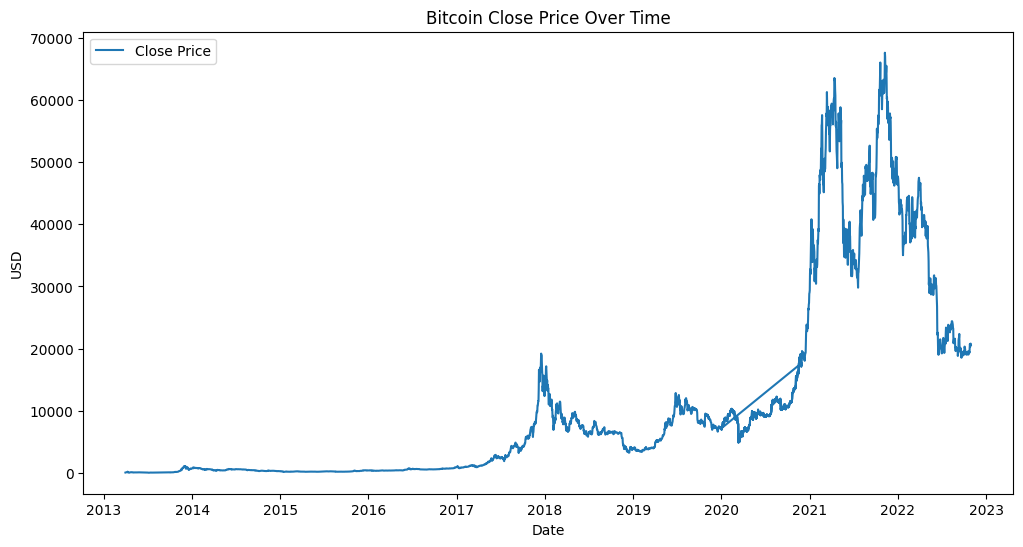

In [64]:
# Visualize Bitcoin Price Trends Over Time

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['close'], label='Close Price')
plt.title('Bitcoin Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('USD')
plt.legend()
plt.show()


#Ensuring consistent plotting after merging datasets with potential gaps or inconsistencies

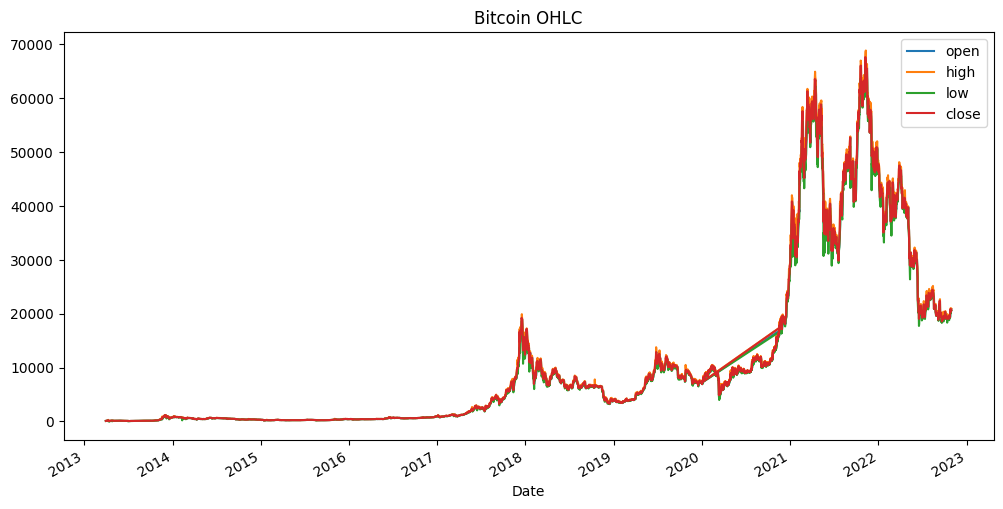

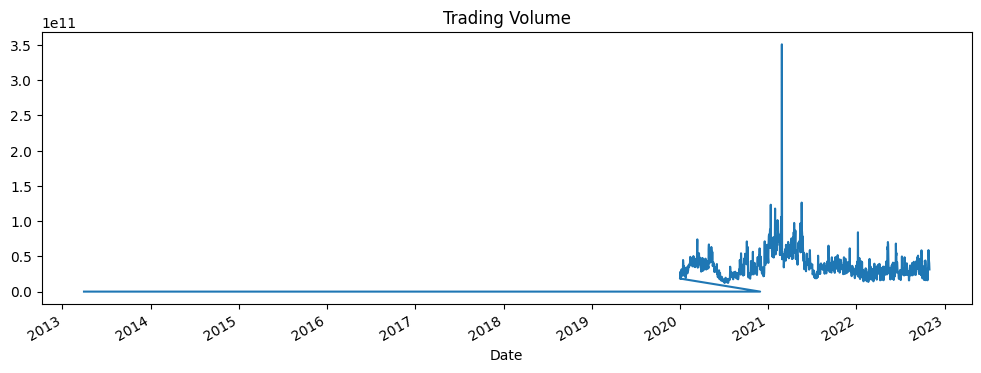

In [65]:
#Comprehensive OHLC Analysis and Trading Volume Trends

df[['open', 'high', 'low', 'close']].plot(figsize=(12, 6), title='Bitcoin OHLC')
plt.show()

df['volume'].plot(figsize=(12, 4), title='Trading Volume')
plt.show()

#Coordinating multiple price metrics and volume data from different sources

In [66]:
# Statistical Analysis and Data Quality Assessment

corr = df.corr(numeric_only=True)
print(corr)
print(df.isna().sum())
print(df.info())
print(df.describe())

            open     close      high       low    volume
open    1.000000  0.998871  0.999544  0.999148  0.737909
close   0.998871  1.000000  0.999493  0.999413  0.736734
high    0.999544  0.999493  1.000000  0.999059  0.740711
low     0.999148  0.999413  0.999059  1.000000  0.731584
volume  0.737909  0.736734  0.740711  0.731584  1.000000
symbol    1034
open         0
close        0
high         0
low          0
volume       0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3827 entries, 2013-03-31 to 2022-10-30
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   symbol  2793 non-null   object 
 1   open    3827 non-null   float64
 2   close   3827 non-null   float64
 3   high    3827 non-null   float64
 4   low     3827 non-null   float64
 5   volume  3827 non-null   float64
dtypes: float64(5), object(1)
memory usage: 209.3+ KB
None
               open         close          high           low        volume


In [67]:
# Export Cleaned and Analyzed Dataset

df.to_csv("bitcoin_data_version2.csv")